<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/Dr_Wonu_Nduka_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Data and Installation

In [ ]:
pip install pandas numpy matplotlib statsmodels tensorflow scikit-learn openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Wonu Data.xlsx to Wonu Data.xlsx


Objective 1: Preprocessing: Incorporation of technical indicators like moving averages and Writing Performance Index (WPI)

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = '/content/Wonu Data.xlsx'  # Update with the correct path
df = pd.read_excel(file_path)

# Moving Average (MA)
def moving_average(df, window=5):
    df[f'MA_{window}'] = df['Writing_Performance'].rolling(window=window).mean()

# Writing Performance Index (WPI)
def wpi(df, window=5):
    delta = df['Writing_Performance'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    wp = gain / loss
    df['WPI'] = 100 - (100 / (1 + wp))

# Apply the functions to the DataFrame
moving_average(df, window=5)
wpi(df, window=5)

# Print necessary parameters
print("Moving Averages:")
print(df[['Writing_Performance', 'MA_5']].tail())  # Adjust the column name as necessary

print("\nWriting Performance Index (WPI):")
print(df[['Writing_Performance', 'WPI']].tail())

# Save the modified DataFrame to a new CSV file
df.to_csv('Wonu_Data_with_indicators.csv', index=False)

Moving Averages:
     Writing_Performance  MA_5
179                   69  69.0
180                   85  76.4
181                   80  78.4
182                   77  76.6
183                   66  75.4

Writing Performance Index (WPI):
     Writing_Performance        WPI
179                   69  47.500000
180                   85  76.056338
181                   80  59.259259
182                   77  39.024390
183                   66  42.105263


Objective 2: Exploratory Data Analysis (EDA): Analysis of trends, seasonality, and correlations

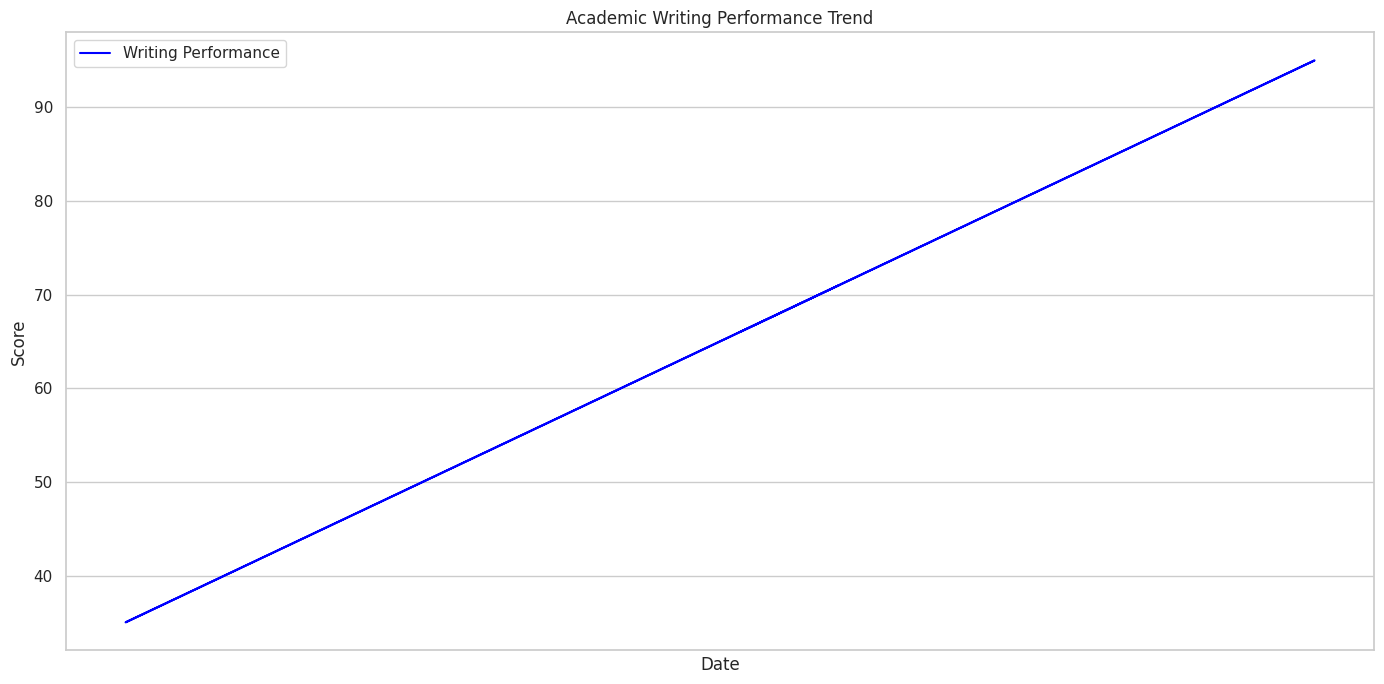

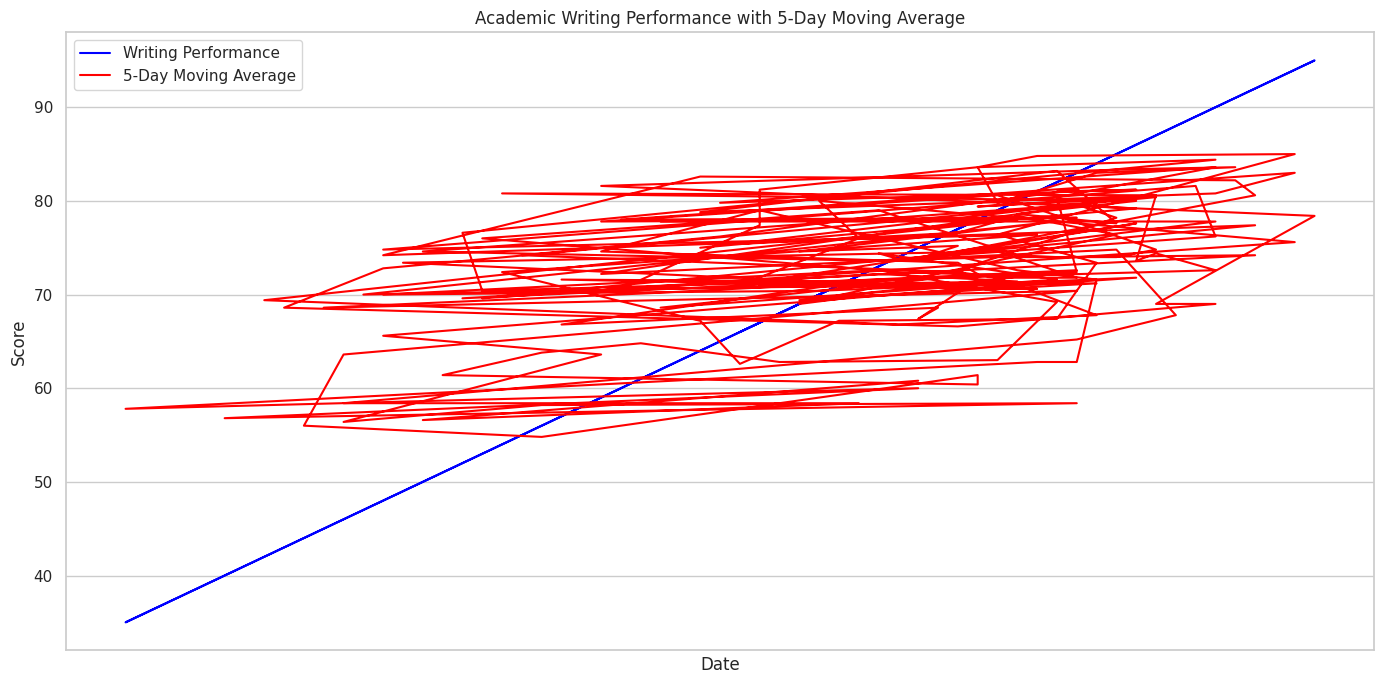

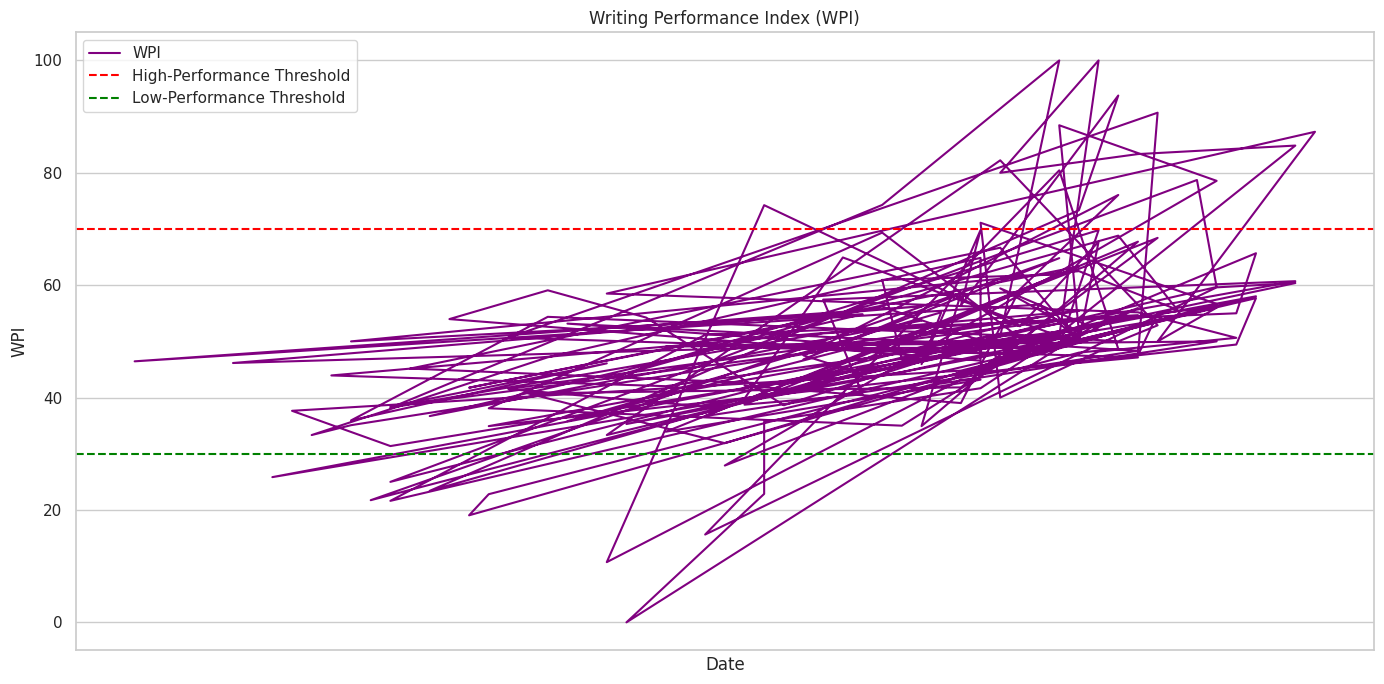

Correlation Matrix:
                     Writing_Performance      MA_5       WPI
Writing_Performance             1.000000  0.462674  0.580511
MA_5                            0.462674  1.000000  0.239916
WPI                             0.580511  0.239916  1.000000


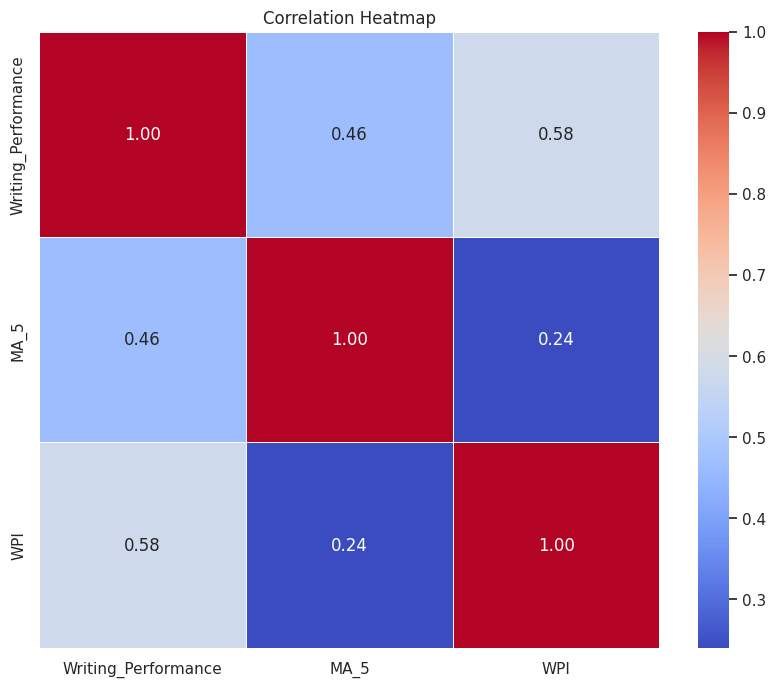

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure 'stock_data_with_indicators.csv' includes technical indicators

# Set plot style
sns.set(style="whitegrid")

# ----> Check if 'Date' column exists and fix if necessary <----
if 'Date' not in df.columns:
    # Assuming the first column represents the date but isn't named 'Date'
    df.insert(0, 'Date', pd.to_datetime(df.iloc[:, 0])) # Convert to datetime if needed
    # Alternatively, rename the existing column:
    # df.rename(columns={'ExistingColumnName': 'Date'}, inplace=True)
    print("Warning: 'Date' column not found. Created/Renamed from the first column.")
# ----> End of fix <----

# Plot writing performance trend
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Writing_Performance'], label='Writing Performance', color='blue') # Corrected column name
plt.title('Academic Writing Performance Trend')
plt.xlabel('Date')
plt.ylabel('Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot moving average
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Writing_Performance'], label='Writing Performance', color='blue')
plt.plot(df['Date'], df['MA_5'], label='5-Day Moving Average', color='red')
plt.title('Academic Writing Performance with 5-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Writing Performance Index (WPI)
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['WPI'], label='WPI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='High-Performance Threshold')
plt.axhline(30, color='green', linestyle='--', label='Low-Performance Threshold')
plt.title('Writing Performance Index (WPI)')
plt.xlabel('Date')
plt.ylabel('WPI')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation analysis
correlation_matrix = df[['Writing_Performance', 'MA_5', 'WPI']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Objective 3: Model Training: Use of a variety of models (Linear Multiple Regression, ARIMAX, LSTM, Random Forest, Support Vector Machine, and Naive Bayes) for Writing Performance VS. Word Count

Linear Regression Coefficients: [ 0.00247682 -0.01735859  0.00948966  0.46155661  0.37970172]
Linear Regression Model:
  RMSE: 9.53
  MSE: 90.88
  MAE: 7.75
  MAPE: 12.01%
  R-squared: 0.56

Random Forest Feature Importances: [0.06173187 0.0649979  0.06896424 0.23188733 0.57241866]
Random Forest Model:
  RMSE: 9.07
  MSE: 82.25
  MAE: 7.64
  MAPE: 11.24%
  R-squared: 0.60

Naive Bayes Model:
  RMSE: 12.56
  MSE: 157.69
  MAE: 9.57
  MAPE: 15.43%
  R-squared: 0.24

Support Vector Machine Model:
  RMSE: 14.95
  MSE: 223.64
  MAE: 11.42
  MAPE: 19.03%
  R-squared: -0.08



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:                 ARIMA(5, 1, 5)   Log Likelihood                -500.603
Date:                Fri, 03 Jan 2025   AIC                           1023.206
Time:                        12:09:29   BIC                           1054.317
Sample:                             0   HQIC                          1035.845
                                - 126                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9074      0.184     -4.936      0.000      -1.268      -0.547
ar.L2          0.0353      0.134      0.263      0.793      -0.228       0.298
ar.L3         -0.7485      0.053    -14.228      0.0

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 50)                  │          11,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,755 (131.86 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,504 (87.91 KB)

None
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
NaNs in y_pred_lstm: 53
LSTM Model:
  RMSE: 74.04
  MSE: 5482.09
  MAE: 72.58
  MAPE: 100.00%
  R-squared: -24.67



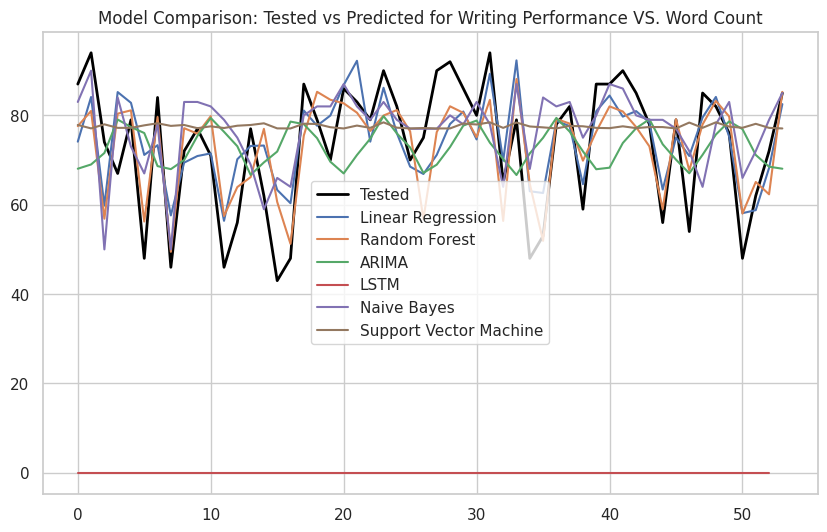

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure 'Wonu_Data_with_indicators.csv' includes technical indicators

# Prepare features and target
# Correct the column names in the features list
features = ['character', 'words', 'sentences', 'MA_5', 'WPI']
target = 'Writing_Performance'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_test)
evaluate_model(y_test, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, 'Random Forest')

# 3. Naive Bayes Model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)
y_pred_nb = naive_bayes_model.predict(X_test)
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

# 4. Support Vector Machine Model
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")

# 5. ARIMA (Using just the 'Writing Performance' series, handle this separately)
# Prepare ARIMA data
y_train_arima = y_train.values
y_test_arima = y_test.values

# Fit ARIMA model (Example with (5,1,5) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,5))  # Now ARIMA is defined
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_test_arima))
evaluate_model(y_test_arima, arima_pred, 'ARIMA')


# 6. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.3, random_state=42)

# Check for NaNs in the test data and predicted data
print("NaNs in y_test_lstm:", np.isnan(y_test_lstm).sum()) # Moved after y_test_lstm definition

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_test_lstm)

print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum()) # Moved after y_pred_lstm definition

# Instead of dropping all rows with NaNs, replace NaNs with a suitable value (e.g., 0)
y_pred_lstm = np.nan_to_num(y_pred_lstm) # Replace NaNs in y_pred_lstm with 0


# Evaluate LSTM model
evaluate_model(y_test_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_test, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_test.values, label='Tested', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Tested vs Predicted for Writing Performance VS. Word Count')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten(),
    'Naive Bayes': y_pred_nb,
    'Support Vector Machine': y_pred_svm
}

plot_comparison(predictions, y_test, predictions)

Writing Performance VS. Readability

Linear Regression Coefficients: [ 3.79071043 -0.91665848 -0.24377995  0.49577765  0.36768439]
Linear Regression Model:
  RMSE: 10.31
  MSE: 106.21
  MAE: 8.66
  MAPE: 13.15%
  R-squared: 0.49

Random Forest Feature Importances: [0.09891116 0.07790896 0.10066704 0.18669652 0.53581632]
Random Forest Model:
  RMSE: 8.77
  MSE: 76.86
  MAE: 7.36
  MAPE: 10.73%
  R-squared: 0.63

Naive Bayes Model:
  RMSE: 10.50
  MSE: 110.30
  MAE: 8.67
  MAPE: 13.49%
  R-squared: 0.47

Support Vector Machine Model:
  RMSE: 12.30
  MSE: 151.30
  MAE: 9.61
  MAPE: 15.87%
  R-squared: 0.27



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:                 ARIMA(5, 1, 5)   Log Likelihood                -500.603
Date:                Fri, 03 Jan 2025   AIC                           1023.206
Time:                        12:08:35   BIC                           1054.317
Sample:                             0   HQIC                          1035.845
                                - 126                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9074      0.184     -4.936      0.000      -1.268      -0.547
ar.L2          0.0353      0.134      0.263      0.793      -0.228       0.298
ar.L3         -0.7485      0.053    -14.228      0.0

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,504 (87.91 KB)

None


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
NaNs in y_pred_lstm: 53
LSTM Model:
  RMSE: 74.04
  MSE: 5482.09
  MAE: 72.58
  MAPE: 100.00%
  R-squared: -24.67



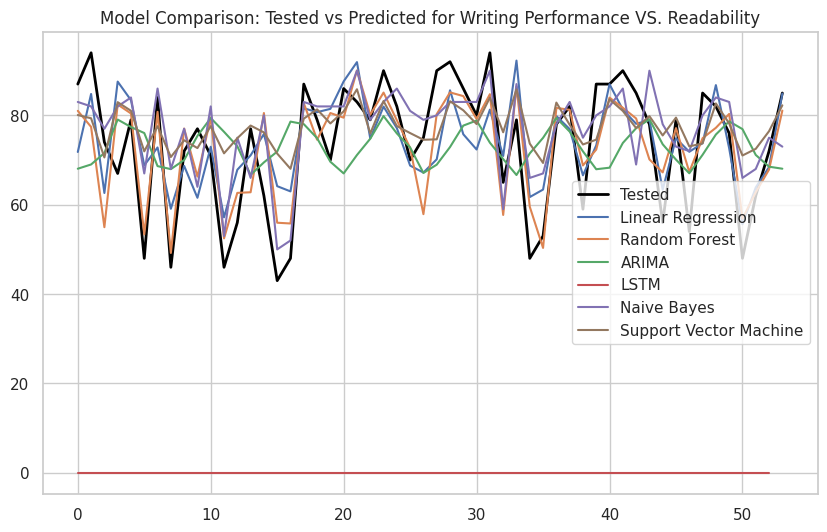

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure 'Wonu_Data_with_indicators.csv' includes technical indicators

# Prepare features and target
# Correct the column names in the features list
features = ['word_length', 'sentence_length', 'readability_score', 'MA_5', 'WPI']
target = 'Writing_Performance'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_test)
evaluate_model(y_test, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, 'Random Forest')

# 3. Naive Bayes Model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)
y_pred_nb = naive_bayes_model.predict(X_test)
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

# 4. Support Vector Machine Model
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")

# 5. ARIMA (Using just the 'Writing Performance' series, handle this separately)
# Prepare ARIMA data
y_train_arima = y_train.values
y_test_arima = y_test.values

# Fit ARIMA model (Example with (5,1,5) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,5))  # Now ARIMA is defined
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_test_arima))
evaluate_model(y_test_arima, arima_pred, 'ARIMA')


# 6. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.3, random_state=42)

# Check for NaNs in the test data and predicted data
print("NaNs in y_test_lstm:", np.isnan(y_test_lstm).sum()) # Moved after y_test_lstm definition

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_test_lstm)

print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum()) # Moved after y_pred_lstm definition

# Instead of dropping all rows with NaNs, replace NaNs with a suitable value (e.g., 0)
y_pred_lstm = np.nan_to_num(y_pred_lstm) # Replace NaNs in y_pred_lstm with 0


# Evaluate LSTM model
evaluate_model(y_test_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_test, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_test.values, label='Tested', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Tested vs Predicted for Writing Performance VS. Readability')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten(),
    'Naive Bayes': y_pred_nb,
    'Support Vector Machine': y_pred_svm
}

plot_comparison(predictions, y_test, predictions)

Writing Performance VS. Vocabulary

Linear Regression Coefficients: [-3.23527134e-01  2.66453526e-15  6.34933731e-01  4.52644066e-01]
Linear Regression Model:
  RMSE: 10.61
  MSE: 112.60
  MAE: 9.08
  MAPE: 13.63%
  R-squared: 0.46

Random Forest Feature Importances: [0.118429   0.         0.28069268 0.60087831]
Random Forest Model:
  RMSE: 9.20
  MSE: 84.59
  MAE: 7.38
  MAPE: 10.89%
  R-squared: 0.59

Naive Bayes Model:
  RMSE: 12.67
  MSE: 160.54
  MAE: 10.39
  MAPE: 14.97%
  R-squared: 0.23

Support Vector Machine Model:
  RMSE: 12.40
  MSE: 153.73
  MAE: 9.85
  MAPE: 16.17%
  R-squared: 0.26



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:                 ARIMA(5, 1, 5)   Log Likelihood                -500.603
Date:                Fri, 03 Jan 2025   AIC                           1023.206
Time:                        12:15:08   BIC                           1054.317
Sample:                             0   HQIC                          1035.845
                                - 126                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9074      0.184     -4.936      0.000      -1.268      -0.547
ar.L2          0.0353      0.134      0.263      0.793      -0.228       0.298
ar.L3         -0.7485      0.053    -14.228      0.0

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

...

 Total params: 33,155 (129.52 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,104 (86.35 KB)

None
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step
NaNs in y_pred_lstm: 53
LSTM Model:
  RMSE: 74.04
  MSE: 5482.09
  MAE: 72.58
  MAPE: 100.00%
  R-squared: -24.67



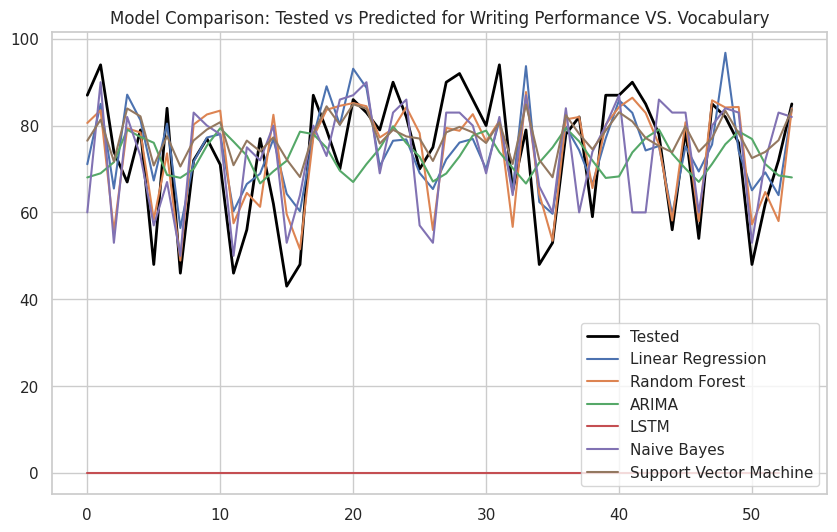

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure 'Wonu_Data_with_indicators.csv' includes technical indicators

# Prepare features and target
# Correct the column names in the features list
# Check if 'rare_words' column exists, if not, create it with default values (e.g., 0)
if 'rare_words' not in df.columns:
    df['rare_words'] = 0  # Or any other suitable default value

features = ['unique_words', 'rare_words', 'MA_5', 'WPI']
target = 'Writing_Performance'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_test)
evaluate_model(y_test, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, 'Random Forest')

# 3. Naive Bayes Model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)
y_pred_nb = naive_bayes_model.predict(X_test)
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

# 4. Support Vector Machine Model
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")

# 5. ARIMA (Using just the 'Writing Performance' series, handle this separately)
# Prepare ARIMA data
y_train_arima = y_train.values
y_test_arima = y_test.values

# Fit ARIMA model (Example with (5,1,5) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,5))  # Now ARIMA is defined
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_test_arima))
evaluate_model(y_test_arima, arima_pred, 'ARIMA')


# 6. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.3, random_state=42)

# Check for NaNs in the test data and predicted data
print("NaNs in y_test_lstm:", np.isnan(y_test_lstm).sum()) # Moved after y_test_lstm definition

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_test_lstm)

print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum()) # Moved after y_pred_lstm definition

# Instead of dropping all rows with NaNs, replace NaNs with a suitable value (e.g., 0)
y_pred_lstm = np.nan_to_num(y_pred_lstm) # Replace NaNs in y_pred_lstm with 0


# Evaluate LSTM model
evaluate_model(y_test_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_test, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_test.values, label='Tested', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Tested vs Predicted for Writing Performance VS. Vocabulary')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten(),
    'Naive Bayes': y_pred_nb,
    'Support Vector Machine': y_pred_svm
}

plot_comparison(predictions, y_test, predictions)

Pooled Model: Writing Performance VS. (Word Count, Readability and Vocabulary)

Linear Regression Coefficients: [ 1.38809851e-03 -1.03697050e-02  8.82637295e-03  2.83324042e+00
 -3.55616251e-01 -1.44784594e-01 -3.60938363e-01  1.17267307e-14
  4.61680204e-01  3.72082271e-01]
Linear Regression Model:
  RMSE: 10.02
  MSE: 100.48
  MAE: 8.24
  MAPE: 12.70%
  R-squared: 0.52

Random Forest Feature Importances: [0.02146925 0.02156271 0.02804542 0.08068436 0.05836766 0.08437348
 0.03573459 0.         0.16307702 0.50668551]
Random Forest Model:
  RMSE: 8.95
  MSE: 80.16
  MAE: 7.58
  MAPE: 11.14%
  R-squared: 0.61

Naive Bayes Model:
  RMSE: 13.42
  MSE: 180.09
  MAE: 10.06
  MAPE: 16.47%
  R-squared: 0.13

Support Vector Machine Model:
  RMSE: 14.96
  MSE: 223.87
  MAE: 11.43
  MAPE: 19.04%
  R-squared: -0.08



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:                 ARIMA(5, 1, 5)   Log Likelihood                -500.603
Date:                Fri, 03 Jan 2025   AIC                           1023.206
Time:                        12:45:31   BIC                           1054.317
Sample:                             0   HQIC                          1035.845
                                - 126                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9074      0.184     -4.936      0.000      -1.268      -0.547
ar.L2          0.0353      0.134      0.263      0.793      -0.228       0.298
ar.L3         -0.7485      0.053    -14.228      0.0

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

...

 Total params: 36,755 (143.58 KB)

 Trainable params: 12,251 (47.86 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,504 (95.72 KB)

None
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
NaNs in y_pred_lstm: 53
LSTM Model:
  RMSE: 74.04
  MSE: 5482.09
  MAE: 72.58
  MAPE: 100.00%
  R-squared: -24.67



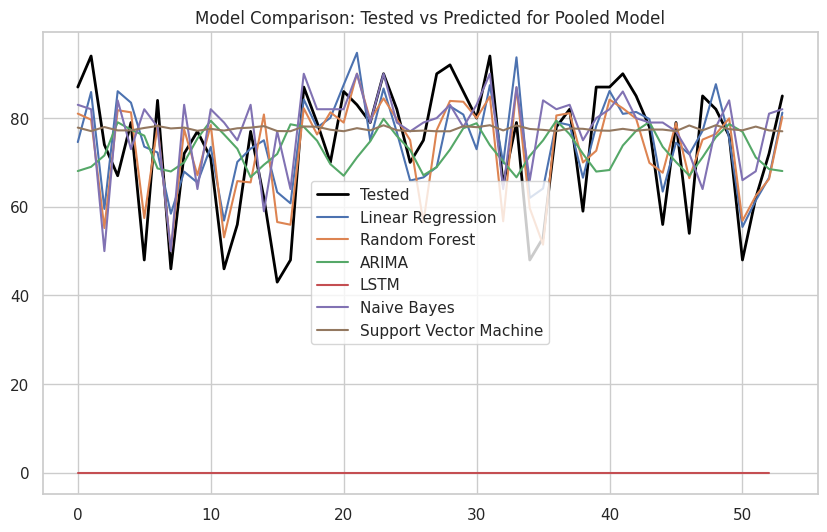

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure 'Wonu_Data_with_indicators.csv' includes technical indicators

# Prepare features and target
# Correct the column names in the features list
# Check if 'rare_words' column exists, if not, create it with default values (e.g., 0)
if 'rare_words' not in df.columns:
    df['rare_words'] = 0  # Or any other suitable default value

features = ['character', 'words', 'sentences', 'word_length', 'sentence_length', 'readability_score', 'unique_words', 'rare_words', 'MA_5', 'WPI']
target = 'Writing_Performance'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_test)
evaluate_model(y_test, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, 'Random Forest')

# 3. Naive Bayes Model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)
y_pred_nb = naive_bayes_model.predict(X_test)
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

# 4. Support Vector Machine Model
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")

# 5. ARIMA (Using just the 'Writing Performance' series, handle this separately)
# Prepare ARIMA data
y_train_arima = y_train.values
y_test_arima = y_test.values

# Fit ARIMA model (Example with (5,1,5) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,5))  # Now ARIMA is defined
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_test_arima))
evaluate_model(y_test_arima, arima_pred, 'ARIMA')


# 6. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.3, random_state=42)

# Check for NaNs in the test data and predicted data
print("NaNs in y_test_lstm:", np.isnan(y_test_lstm).sum()) # Moved after y_test_lstm definition

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_test_lstm)

print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum()) # Moved after y_pred_lstm definition

# Instead of dropping all rows with NaNs, replace NaNs with a suitable value (e.g., 0)
y_pred_lstm = np.nan_to_num(y_pred_lstm) # Replace NaNs in y_pred_lstm with 0


# Evaluate LSTM model
evaluate_model(y_test_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_test, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_test.values, label='Tested', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Tested vs Predicted for Pooled Model')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten(),
    'Naive Bayes': y_pred_nb,
    'Support Vector Machine': y_pred_svm
}

plot_comparison(predictions, y_test, predictions)

Forecast using Random Forest Model

<ipython-input-44-452c947e4b50>:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_data = pd.concat([future_data, new_data])


12-Lead Forecasted Writing Performance (Random Forest):
Step 1: Prediction = 66.22, Lower 95% CI = 63.37, Upper 95% CI = 69.07
Step 2: Prediction = 66.22, Lower 95% CI = 63.37, Upper 95% CI = 69.07
Step 3: Prediction = 66.22, Lower 95% CI = 63.37, Upper 95% CI = 69.07
Step 4: Prediction = 66.22, Lower 95% CI = 63.37, Upper 95% CI = 69.07
Step 5: Prediction = 66.22, Lower 95% CI = 63.37, Upper 95% CI = 69.07
Step 6: Prediction = 66.16, Lower 95% CI = 63.31, Upper 95% CI = 69.01
Step 7: Prediction = 66.56, Lower 95% CI = 63.71, Upper 95% CI = 69.41
Step 8: Prediction = 66.56, Lower 95% CI = 63.71, Upper 95% CI = 69.41
Step 9: Prediction = 66.56, Lower 95% CI = 63.71, Upper 95% CI = 69.41
Step 10: Prediction = 66.56, Lower 95% CI = 63.71, Upper 95% CI = 69.41
Step 11: Prediction = 66.92, Lower 95% CI = 64.07, Upper 95% CI = 69.77
Step 12: Prediction = 66.92, Lower 95% CI = 64.07, Upper 95% CI = 69.77


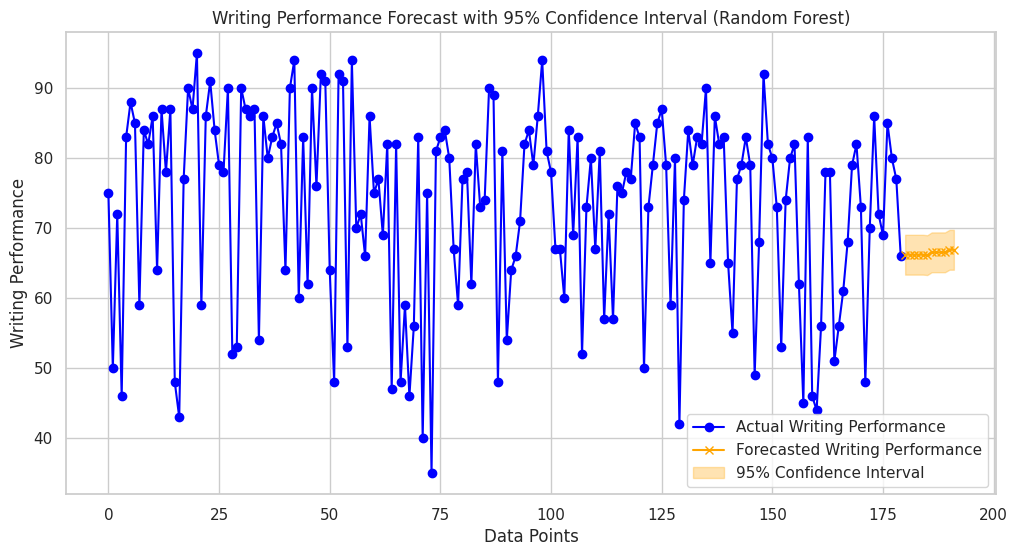

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure the file is available and correct

# Prepare features and target
if 'rare_words' not in df.columns:
    df['rare_words'] = 0  # Add missing column if necessary

features = ['character', 'words', 'sentences', 'word_length', 'sentence_length',
            'readability_score', 'unique_words', 'rare_words', 'MA_5', 'WPI']
target = 'Writing_Performance'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Generate 12-lead forecast
future_steps = 12
last_data = X.iloc[-1:]  # Get the last row as a template
future_data = pd.DataFrame(columns=X.columns)

# Generate synthetic future data
for i in range(future_steps):
    new_data = last_data.copy()
    new_data['readability_score'] += (i + 1) * 0.1
    new_data['MA_5'] += (i + 1) * 0.05
    future_data = pd.concat([future_data, new_data])

# Predict Writing Performance and calculate confidence intervals
rf_forecast = rf_model.predict(future_data)
std_dev = np.std(y_pred_rf)  # Standard deviation of the predictions on test set
confidence_interval = 1.96 * std_dev / np.sqrt(len(y_pred_rf))

upper_bound = rf_forecast + confidence_interval
lower_bound = rf_forecast - confidence_interval

# Print forecasted values with confidence intervals
print("12-Lead Forecasted Writing Performance (Random Forest):")
for i in range(future_steps):
    print(f"Step {i+1}: Prediction = {rf_forecast[i]:.2f}, Lower 95% CI = {lower_bound[i]:.2f}, Upper 95% CI = {upper_bound[i]:.2f}")

# Plot actual and forecasted values with confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(y.values, label="Actual Writing Performance", color='blue', marker='o')
plt.plot(range(len(y), len(y) + future_steps), rf_forecast, label="Forecasted Writing Performance", color='orange', marker='x')
plt.fill_between(range(len(y), len(y) + future_steps), lower_bound, upper_bound, color='orange', alpha=0.3, label="95% Confidence Interval")
plt.title("Writing Performance Forecast with 95% Confidence Interval (Random Forest)")
plt.xlabel("Data Points")
plt.ylabel("Writing Performance")
plt.legend()
plt.show()

Actionable Insights

In [ ]:
!pip install shap # install the missing package

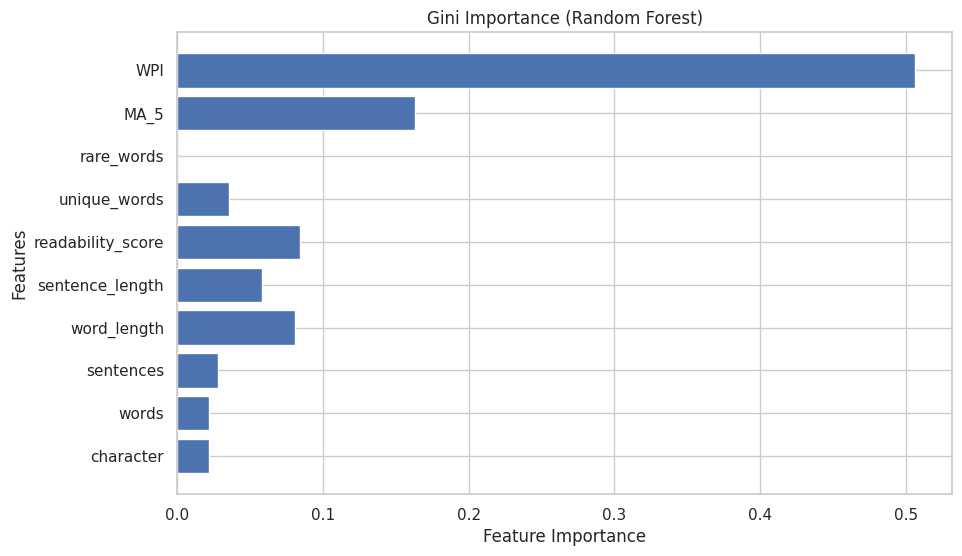

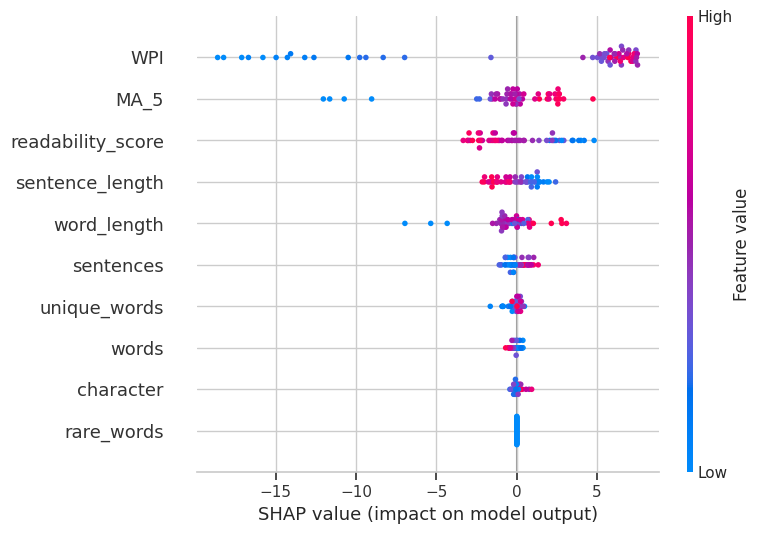

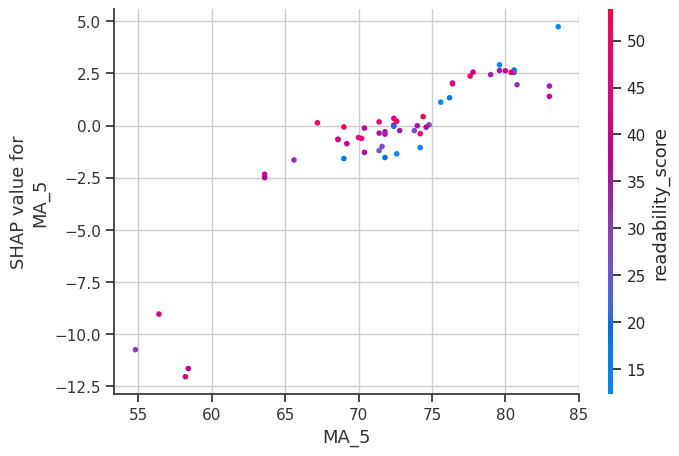

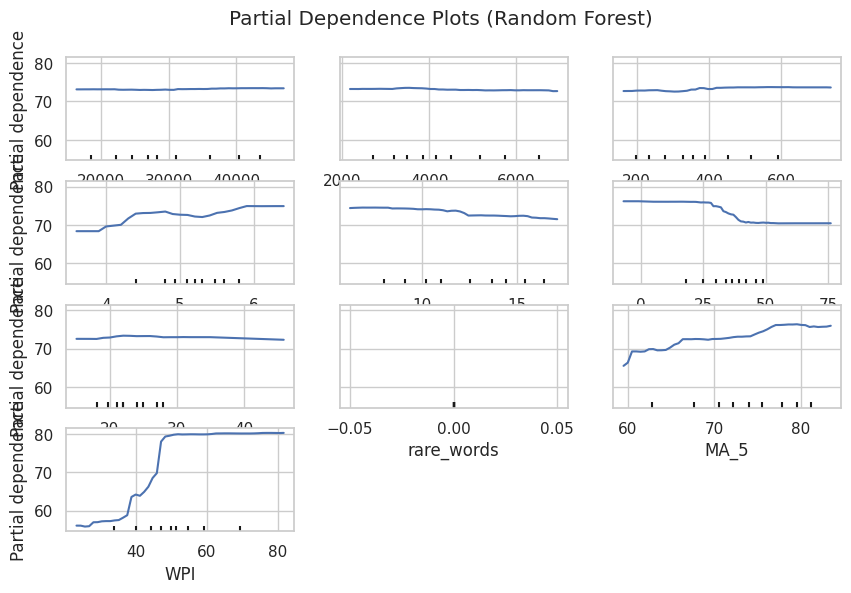

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap # import the installed package
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay # import the PartialDependenceDisplay class
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('Wonu_Data_with_indicators.csv')  # Ensure the file is available and correct

# Prepare features and target
if 'rare_words' not in df.columns:
    df['rare_words'] = 0  # Add missing column if necessary

features = ['character', 'words', 'sentences', 'word_length', 'sentence_length',
            'readability_score', 'unique_words', 'rare_words', 'MA_5', 'WPI']
target = 'Writing_Performance'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Gini Importance using Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance (Gini importance)
gini_importance = rf_model.feature_importances_

# Plot Gini importance
plt.figure(figsize=(10, 6))
plt.barh(features, gini_importance)
plt.title("Gini Importance (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

# 2. SHAP (SHapley Additive exPlanations) values using Random Forest
# Create SHAP explainer for Random Forest
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test)

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=features)

# Plot SHAP dependence plot for a specific feature (e.g., MA_5)
# Access the values of the Explanation object
shap.dependence_plot('MA_5', shap_values.values, X_test)

# 3. Partial Dependence Plots (PDP)
fig, ax = plt.subplots(figsize=(10, 6))
# Use PartialDependenceDisplay.from_estimator instead of plot_partial_dependence
display = PartialDependenceDisplay.from_estimator(
    rf_model, X_train, features, grid_resolution=50, ax=ax
)
plt.suptitle('Partial Dependence Plots (Random Forest)')
plt.subplots_adjust(top=0.9)
plt.show()